In [17]:

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report, roc_curve)
data = pd.DataFrame({
    "shoe_size_eu": [36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 38, 39, 39, 42, 42],
    "gender":       ["F","F","F","F","F","M","M","M","M","M","F","F","M","M","F"]
})
X = data[["shoe_size_eu"]].values
y = data["gender"].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.66, random_state=41, stratify=y)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred_stat111 = knn.predict_proba(X_test)
print(y_pred_stat111)
y_pred = knn.predict(X_test)
print(X_test)
print("predikcija")
print(y_pred)
print("istina")
print(y_test)
labels = ["M","F"]
cm = confusion_matrix(y_test, y_pred, labels=labels)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label="M")
rec = recall_score(y_test, y_pred, pos_label="M")
f1 = f1_score(y_test, y_pred, pos_label="M")
report = classification_report(y_test, y_pred, digits=4, zero_division=0)

print(f"labels={labels}")
print(cm)
print(f"accuracy : {acc:.4f}")
print(f"precision: {prec:.4f}")
print(f"recall   : {rec:.4f}")
print(f"f1       : {f1:.4f}")
print("\n=== Classification Report ===")
print(report)


#Ako želiš `pos_label='F'` (umjesto `'M'`), samo promijeni `pos_label` u trima metrikama ili dodaj drugi blok ispisa za `'F'`.


[[1.         0.        ]
 [0.33333333 0.66666667]
 [1.         0.        ]
 [0.33333333 0.66666667]
 [1.         0.        ]
 [1.         0.        ]
 [0.66666667 0.33333333]
 [0.33333333 0.66666667]
 [1.         0.        ]
 [0.33333333 0.66666667]]
[[40]
 [43]
 [39]
 [42]
 [39]
 [38]
 [41]
 [42]
 [36]
 [42]]
predikcija
['F' 'M' 'F' 'M' 'F' 'F' 'F' 'M' 'F' 'M']
istina
['F' 'M' 'M' 'M' 'F' 'F' 'M' 'M' 'F' 'F']
labels=['M', 'F']
[[3 2]
 [1 4]]
accuracy : 0.7000
precision: 0.7500
recall   : 0.6000
f1       : 0.6667

=== Classification Report ===
              precision    recall  f1-score   support

           F     0.6667    0.8000    0.7273         5
           M     0.7500    0.6000    0.6667         5

    accuracy                         0.7000        10
   macro avg     0.7083    0.7000    0.6970        10
weighted avg     0.7083    0.7000    0.6970        10



In [34]:
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np

y_pred_stat = knn.predict_proba(X_test)[:, 1]
print(y_pred_stat)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_stat, pos_label='M')

roc_matrix = np.column_stack((fpr, tpr, thresholds))
print("NumPy matrica (prvih 5 redaka):")
print(roc_matrix[:5])

#testni kod za igru da dobijemo prag za željeni traget_recall
target_recall = 0.9
idx = np.where(tpr >= target_recall)[0]
thr_for_recall = thresholds[idx[0]] if len(idx) else 0.5
print(thr_for_recall)

y_pred_custom = (y_pred_stat >= 0.3).astype(int)
print(y_pred_custom)
print(np.where(y_test == "M", 1, 0))

[0.         0.66666667 0.         0.66666667 0.         0.
 0.33333333 0.66666667 0.         0.66666667]
NumPy matrica (prvih 5 redaka):
[[0.         0.                inf]
 [0.2        0.6        0.66666667]
 [0.2        0.8        0.33333333]
 [1.         1.         0.        ]]
0.0
[0 1 0 1 0 0 1 1 0 1]
[0 1 1 1 0 0 1 1 0 0]


In [2]:
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np

y_pred_stat = knn.predict_proba(X_test)[:, 1]
#prob_true = (gnb.fit(iris_1c_train_ftrs, iris_1c_train_tgt).predict_proba(iris_1c_test_ftrs)[:, 1]) # [:, 1]=="True"
print(y_pred_stat)


# y_true: stvarne oznake (0/1), probs: P(y=1|x) iz predict_proba
fpr, tpr, thresholds = roc_curve(y_test, y_pred_stat, pos_label='M')

# Primjer 1: Youdenov indeks (maksimizira TPR - FPR)
j = tpr - fpr
best_idx = np.argmax(j)
best_thr = thresholds[best_idx]
print(j, best_idx, best_thr)

# Primjer 2: prag najbliži idealnoj točki (FPR=0, TPR=1)
dist = np.sqrt((fpr - 0)**2 + (tpr - 1)**2)
best_idx2 = np.argmin(dist)
best_thr2 = thresholds[best_idx2]
print(j, best_idx2, best_thr2)
# Primjer 3: odaberi prag za ciljani recall (npr. >= 0.90)
target_recall = 0.8
idx = np.where(tpr >= target_recall)[0]
thr_for_recall = thresholds[idx[0]] if len(idx) else 0.5
print(thr_for_recall)

y_pred_custom = (y_pred_stat >= 0.5).astype(int)
print(y_pred_custom)



[0.         0.66666667 0.         0.66666667 0.         0.
 0.33333333 0.66666667 0.         0.66666667]
[0.  0.4 0.6 0. ] 2 0.3333333333333333
[0.  0.4 0.6 0. ] 2 0.3333333333333333
0.3333333333333333
[0 1 0 1 0 0 0 1 0 1]


   FPR  TPR  Threshold
0  0.0  0.0        inf
1  0.2  0.6   0.666667
2  0.2  0.8   0.333333
3  1.0  1.0   0.000000


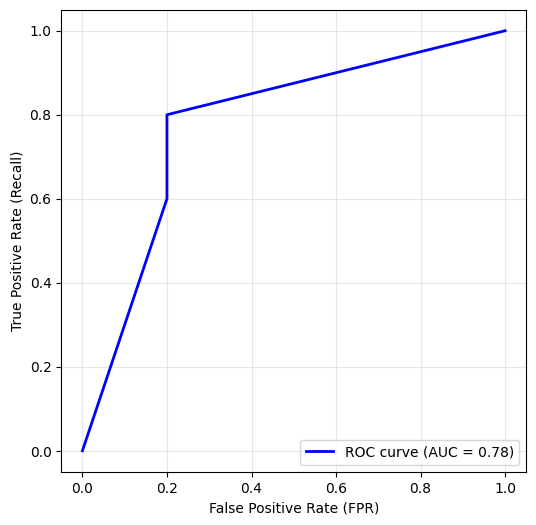

In [35]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
# Pretpostavljamo da već imaš y_true (0/1) i probs = predict_proba(X)[:, 1]
# Ako nemaš, ovako bi ih dobio primjerice s treniranim modelom:
# probs = clf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_stat, pos_label='M')
roc_auc = roc_auc_score(y_test, y_pred_stat)
roc_df = pd.DataFrame({
    "FPR": fpr,
    "TPR": tpr,
    "Threshold": thresholds
})
print(roc_df.head(20))  # ispis prvih 10 redova
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (Recall)")
#plt.title("ROC krivulja")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


In [4]:
from sklearn.metrics import recall_score

# 5) Nađi prag za recall=1
# filtriramo sve pragove gdje je TPR=1
candidates = roc_df[roc_df["TPR"] == 1.0]

if not candidates.empty:
    # uzmi najveći prag među njima (najstroži, ali još uvijek recall=1)
    best_threshold = candidates["Threshold"].max()
else:
    best_threshold = 0.5  # fallback

print(f"Odabrani prag za recall=1: {best_threshold:.4f}")

# 6) Primijeni prag na test skupu
y_pred_custom = (y_pred_stat >= best_threshold).astype(int)
# Convert y_test to integer labels (0 and 1) to match y_pred_custom format
y_test_binary = (y_test == 'M').astype(int)


# 7) Provjeri recall
rec = recall_score(y_test_binary, y_pred_custom, pos_label=1) # Use y_test_binary and pos_label=1
print("Recall s custom pragom =", rec)

Odabrani prag za recall=1: 0.0000
Recall s custom pragom = 1.0


In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
# Pretpostavka: imaš probs = clf.predict_proba(X_test)[:,1], y_test i thresholds iz roc_curve
def plot_confusion_matrices_for_thresholds(y_true, probs, thresholds, max_plots=6):
    """
    Nacrta confusion matrix za odabrane pragove.
    max_plots = koliko najviše matrica da prikaže (da ne zatrpa ekran).
    """
    n = min(len(thresholds), max_plots)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))

    if n == 1:
        axes = [axes]  # da bude iterable
    # Convert y_true to numerical labels (0 or 1)
    y_true_binary = (y_true == 'M').astype(int)
    for ax, thr in zip(axes, thresholds[:n]):
        y_pred = np.where(probs >= thr, 1, 0)
        cm = confusion_matrix(y_true_binary, y_pred, labels=[1,0])
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=["1","0"], yticklabels=["1","0"], ax=ax)
        ax.set_title(f"Threshold = {thr:.2f}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
    plt.tight_layout()
    plt.show()

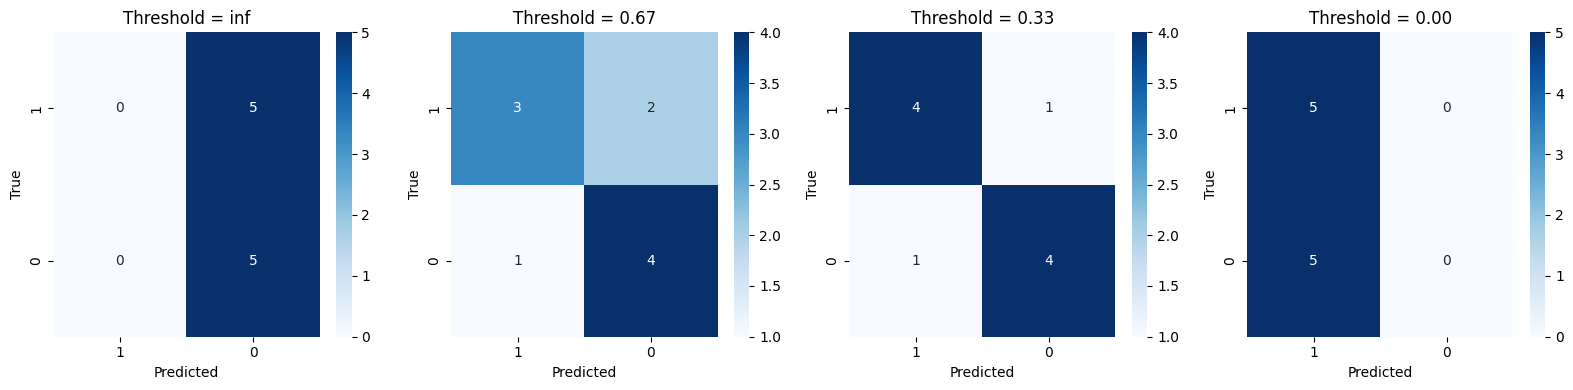

In [37]:
probs = knn.predict_proba(X_test)[:, 1]
plot_confusion_matrices_for_thresholds(y_test, probs, thresholds, max_plots=6)

In [24]:
y_pred_stat = knn.predict_proba(X_test)[:, 1]
#prob_true = (gnb.fit(iris_1c_train_ftrs, iris_1c_train_tgt).predict_proba(iris_1c_test_ftrs)[:, 1]) # [:, 1]=="True"
print(y_pred_stat)

[0.         0.66666667 0.         0.66666667 0.         0.
 0.33333333 0.66666667 0.         0.66666667]
